<a href="https://colab.research.google.com/github/nnott3/KilterTransformer/blob/main/notebooks/gpt_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# init

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!git clone https://github.com/nnott3/KilterTransformer.git
%cd KilterTransformer
!ls

Mounted at /content/drive
Cloning into 'KilterTransformer'...
remote: Enumerating objects: 368, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (157/157), done.
remote: Total 368 (delta 111), reused 86 (delta 36), pack-reused 173 (from 1)
Receiving objects: 100% (368/368), 129.82 MiB | 12.44 MiB/s, done.
Resolving deltas: 100% (184/184), done.
Updating files: 100% (60/60), done.
/content/KilterTransformer
bert_improved.ipynb  gitignore		notebooks	   saved_models
bert.ipynb	     gpt_shuffle.ipynb	project_structure  src
data		     gpt_wandb.ipynb	pyproject.toml	   utils_old
EDA.ipynb	     main.ipynb		readme.md	   uv.lock
figs		     models		req


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import sys
import json
import random
import warnings
from datetime import datetime
from functools import partial
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb
from datasets import Dataset, disable_progress_bar
from transformers import (
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback,
    GPT2Config,
    GPT2LMHeadModel,
    LogitsProcessor,
    LogitsProcessorList,
    PreTrainedTokenizerFast,
    Trainer,
    TrainingArguments,
)


# project_root = Path(__file__).resolve().parent.parent if '__file__' in globals() else Path.cwd().parent

# os.chdir(project_root)
# sys.path.insert(0, str(project_root))
os.getcwd()

from src.data_processing import DataPreprocessing
from src.tokenizer import build_vocab, tokenize_datasets, train_tokenizer
from src.visualization import Visualization
# from src.gpt import KilterGPT


# init train

In [24]:
project = "climb-gpt-new"
use_custom_loss = False #############
use_data_augment = False #############

run_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_{'defaultloss' if not use_custom_loss else 'newloss'}_{'noaugment' if not use_data_augment else 'augmented'}"

OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_new/{run_name}"
# OUT_DIR = f"models/climb_gpt_new/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dp = DataPreprocessing()
datasets = dp.load_climbs()

# 80-10-10 split
train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {
    'train': train_test['train'],
    'val': val_test['train'],
    'test': val_test['test']
}

tokenizer = train_tokenizer(datasets, OUT_DIR)
datasets = tokenize_datasets(datasets, tokenizer)

wandb_config={
        "n_embd": 256,
        "n_head": 4,
        "n_layer": 6,
        "n_positions": 128,
        "dropout": 0.1,
        "epochs": 20,
        "batch_size": 16,
        "learning_rate": 1e-5,
        "weight_decay": 0.01,
        "gradient_accumulation_steps": 1,
        "early_stopping_patience": 5,
        "allow_empty_prompt": True,
        "min_prefix_len": 1,
    }
wandb.init(
    project=project,
    name=run_name,
    config=wandb_config,
)



Using device: cuda
Loaded 76992 routes from cache data/climbs_cleaned.csv
Built vocab with 1932 tokens (1928 custom)

Vocab size: 1932 tokens
First 10 tokens: [('hand1344', 1251), ('finish1340', 1723), ('grade25', 25), ('feet1190', 145), ('hand1264', 1171), ('feet1125', 80), ('start1218', 649), ('start1118', 549), ('feet1392', 347), ('hand1354', 1261)]

Sample encodings:

Input:  angle35_grade14_feet1595_start1400
Tokens: ['[BOS]', 'angle35', 'grade14', 'feet1595', '[UNK]', '[EOS]', '[PAD]x19']

Input:  angle40_grade15_feet1595_start1596_hand1597_finish1598
Tokens: ['[BOS]', 'angle40', 'grade15', 'feet1595', 'start1596', 'hand1597', 'finish1598', '[EOS]', '[PAD]x17']

Saving tokenizer to /content/drive/MyDrive/KilterTransformer/models/climb_gpt_new/20251111_061212_gpt_new


In [ ]:
for k,v in datasets['train'][0].items():
    print(f'{k: <15}: {v}')

input_ids      : [1, 9, 23, 35, 37, 580, 1141, 1188, 1240, 1253, 1762, 450, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
token_type_ids : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
labels         : [-100, 9, 23, 35, 37, 580, 1141, 1188, 1240, 1253, 1762, 450, 2, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]


# default gpt

In [25]:
class KilterGPT(nn.Module):
    def __init__(self,
                tokenizer: PreTrainedTokenizerFast,
                n_embd: int = 256,
                n_head: int = 4,
                n_layer: int = 6,
                n_positions: int = 128,
                dropout: float = 0.1,
                use_custom_loss: bool = False,
                use_data_augment: bool = False,
                device: str = "cpu",
                ):
        super().__init__()

        self.tokenizer = tokenizer
        self.vocab_size = tokenizer.vocab_size

        self.config = GPT2Config(
            n_embd=n_embd,
            n_head=n_head,
            n_layer=n_layer,
            n_positions=n_positions,
            n_ctx=n_positions,
            resid_pdrop=dropout,
            embd_pdrop=dropout,
            attn_pdrop=dropout,
            vocab_size=tokenizer.vocab_size,
            )
        self.model = GPT2LMHeadModel(self.config)

        self.use_custom_loss = use_custom_loss
        self.use_data_augment = use_data_augment
        self.device = device

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):

        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, labels=labels)

        if self.use_custom_loss:
            if labels is not None:
                # Order-invariant loss: any remaining hold in the sequence is valid
                logits = outputs.logits
                shift_logits = logits[..., :-1, :].contiguous()
                shift_labels = labels[..., 1:].contiguous()

                # Use vectorized loss function
                loss = self._any_of_next_token_loss_vectorized(shift_logits, shift_labels)
                outputs.loss = loss

        return outputs

    @staticmethod
    def _any_of_next_token_loss_vectorized(logits, shift_labels, ignore_index=-100,
                                       bos_token_id=1, eos_token_id=2, print_debug=False):
        """
        Order-invariant loss for climbing routes.

        Loss behavior:
        - BOS (token_id=1): Never predicted (always first in sequence)
        - Angle, Grade, Holds: Set-loss (order-invariant, any remaining token is valid)
        - EOS (token_id=2): Excluded from valid set (standard single-target prediction)
        - Padding: Ignored

        Args:
            logits: (B, L, V) # batch_size, seq_len, vocab_size
            shift_labels: (B, L)
            ignore_index: Padding marker (default -100)
            bos_token_id: BOS token ID (default 1)
            eos_token_id: EOS token ID (default 2)
        """
        B, L, V = logits.shape
        device = logits.device

        # Compute log probabilities
        log_probs = F.log_softmax(logits, dim=-1)  # (B, L, V)

        # mask for valid label positions
        # [TRUE, TRUE, TRUE, TRUE, FALSE, FALSE, ...] where FALSE are PADs
        valid_positions = (shift_labels != ignore_index)  # (B, L)


        # upper-triangle of 1 size (L, L)
        future_mask = torch.triu(torch.ones((L, L), device=device, dtype=torch.bool))

        # Combine: for each sequence, each position sees all future tokens that are valid
        # Expand: valid_positions.unsqueeze(1): (B, L) → (B, 1, L)
        # valid_future_mask[b, i, j] = True if label[j] is valid future of i and j >= i
        valid_future_mask = valid_positions.unsqueeze(1) & future_mask  # (B, L, L)
        # valid_future_mask[0][0] => [TRUE, TRUE, TRUE, ..., TRUE, FALSE, ..., FALSE] (True for all valid tokens + False for PADs)
        # valid_future_mask[0][1] => [FALSE, TRUE, TRUE, ..., TRUE, FALSE, ..., FALSE]
        # valid_future_mask[0][2] => [FALSE, FALSE, TRUE, ..., TRUE, FALSE, ..., FALSE]
        # valid_future_mask[0][-seq_len] => [FALSE, FALSE, FALSE, ..., FALSE, FALSE, ..., FALSE]


        labels_expanded = shift_labels.unsqueeze(1).expand(-1, L, -1)  # (B, L, L)
        # labels_expanded[0] => (B, L) 2d array, row count = batch_size B=16
        # each row labels_expanded[0][0] is [token0, token1, token2, ..., token_seq_len, -100, -100, ...] (len L=21)

        # Set ignored ones to -1
        labels_expanded = torch.where(valid_future_mask, labels_expanded, -torch.ones_like(labels_expanded))
        # each row labels_expanded[0][0] is now [token0, token1, token2, ..., token_seq_len, -1, -1, ...] (len L=21)
        # labels_expanded[0][0] => [token0, token1, token2, ..., token_seq_len, -1, -1, ...] (len L=21)
        # labels_expanded[0][1] => [-1,     token1, token2, ..., token_seq_len, -1, -1, ...]
        # labels_expanded[0][2] => [-1,       -1,   token2, ..., token_seq_len, -1, -1, ...]


        # ========================================================================
        # NEW: Exclude EOS from the valid set (EOS should be predicted exactly, not as part of set)
        # ========================================================================
        # Create mask for EOS tokens in future positions
        # Shape: (B, L, L) - True where future token is EOS
        is_eos_future = (labels_expanded == eos_token_id)

        # Remove EOS from valid_future_mask
        # This makes EOS tokens NOT contribute to the set-loss
        # They will only be predicted when they are the ONLY remaining token
        valid_future_mask = valid_future_mask & ~is_eos_future
        # Explanation:
        # Before: valid_future_mask[0][i] might include EOS among valid predictions
        # After:  valid_future_mask[0][i] excludes EOS from the set
        # Result: When predicting, model won't see EOS as "any valid token"
        #         EOS only gets predicted when it's the last token (standard behavior)


        # Build boolean mask per vocab id using scatter_
        valid_token_mask = torch.zeros((B, L, V), dtype=torch.bool, device=device)
        scatter_idx = labels_expanded.clone()
        scatter_idx[scatter_idx < 0] = 0  # convert -1 to dummy 0, to ignore the positions

        valid_token_mask.scatter_(dim=2, index=scatter_idx, src=valid_future_mask)  # mark valid vocab positions
        # (B, L, V)(16, 21, 1932)
        # valid_token_mask[0][0]
        # [PAD, BOS, EOS, UNK, ---angle---, ---grade---, ---holds---]
        # valid_token_mask[0][0], sum=12 < seq_len
        # [FALSE, TRUE, FALSE, ---one True angle, ---one True grade, ---several True holds---]
        #              ^^^^^ NOTE: EOS is now FALSE (excluded from set)

        # valid_token_mask[0][1], sum=11
        # [FALSE, FALSE, FALSE, ---one True angle, ---one True grade, ---several True holds---]
        #         ^^^^^ BOS excluded    ^^^^^ EOS excluded

        # valid_token_mask[0][2], sum=10
        # [FALSE, FALSE, FALSE, ---all False angle, ---one True grade, ---several True holds---]

        # valid_token_mask[0][3], sum=9
        # [FALSE, FALSE, FALSE, ---all False angle, ---all False grade, ---several True holds---]

        # and then the hold tokens ...

        # note, for next example in batch:
        # valid_token_mask[1][0], sum=17 < seq_len
        # [FALSE, TRUE, FALSE, ---one True angle, ---one True grade, ---several True holds---]

        valid_token_mask[:, :, 0] &= (labels_expanded[:, :, 0] != 0)  # fix dummy zeros if any


        # ========================================================================
        # NEW: Add back EOS prediction when it's the only valid next token
        # ========================================================================
        # Find positions where the next token should be EOS
        # Shape: (B, L)
        next_is_eos = (shift_labels == eos_token_id)

        # At these positions, enable EOS in the vocabulary mask
        # This allows standard cross-entropy loss for EOS prediction
        valid_token_mask[:, :, eos_token_id] |= next_is_eos
        # Explanation:
        # If position i should predict EOS (next_is_eos[b,i] = True):
        #   - Set valid_token_mask[b, i, eos_token_id] = True
        #   - This makes ONLY EOS valid at this position
        #   - Standard single-target prediction for EOS!
        '''
        valid_token_mask[:, :, bos_token_id] = False
        '''

        # Filter(/mask) log_probs for only valid positions
        masked_log_probs = torch.where(valid_token_mask, log_probs, torch.full_like(log_probs, -1e9))
        # log_probs[0][0] =>        [-7.6137, -6.4946, -7.7223, ...] the usual
        # valid_token_mask[0][0] => [FALSE,    TRUE,    FALSE,   ...] (BOS and EOS excluded)
        # masked_log_probs[0][0] => [-1e9,    -6.4946,  -1e9,   ...]


        # Combine log(P(token1) + P(token2) + ... + P(tokenN))
        log_sum = torch.logsumexp(masked_log_probs, dim=-1)  # (B, L)
        # For positions with multiple valid tokens: log(P1 + P2 + ... + PN) = set-loss
        # For positions with only EOS valid: log(P_eos) = standard single-target loss


        # log(P1) + log(P2) + ... + log(PN)
        # count_valid = valid_token_mask.sum(dim=-1).clamp(min=1)
        # log_sum = masked_log_probs.sum(dim=-1) / count_valid


        # Only keep positions that had at least one valid target
        has_valid = valid_token_mask.any(dim=-1) # Shape: (B, L)

        # average negative log-likelihood
        loss = -log_sum[has_valid].mean()
        # loss = -log_sum[has_valid].sum() / valid_positions.sum()


        if print_debug:
            print("\n" + "="*70)
            print("DEBUG: Loss Computation Details")
            print("="*70)
            print(f"\nSequence 0 breakdown:")
            for i in range(min(8, L)):
                if has_valid[0, i]:
                    valid_tokens = [j for j in range(V) if valid_token_mask[0, i, j]]
                    num_valid = len(valid_tokens)
                    is_eos_pos = next_is_eos[0, i].item()
                    print(f"  Pos {i}: {num_valid} valid tokens | Target={shift_labels[0,i].item():4d} | "
                        f"EOS-only={is_eos_pos} | log_sum={log_sum[0,i].item():7.3f}")


        return loss

    @classmethod
    def load_from_checkpoint(cls, checkpoint_dir: str, datasets):

        """Load model, tokenizer, and config from checkpoint directory.

        Args:
            checkpoint_dir: Path to checkpoint folder (e.g., OUT_DIR or OUT_DIR/checkpoint-XXX)
            device: Device to load model on

        Returns:
            Loaded KilterGPT instance
        """
        device = "cuda" if torch.cuda.is_available() else "cpu"
        checkpoint_path = Path(checkpoint_dir)


        # Find latest checkpoint if given OUT_DIR
        if not (checkpoint_path / "pytorch_model.bin").exists():
            checkpoints = sorted(checkpoint_path.glob("checkpoint-*"))
            if not checkpoints:
                raise FileNotFoundError(f"No checkpoints found in {checkpoint_dir}")
            checkpoint_path = checkpoints[-1]
            print(f"Loading from: {checkpoint_path}")

        # Load tokenizer
        tokenizer = PreTrainedTokenizerFast.from_pretrained(checkpoint_path)

        # Initialize model with correct architecture
        model = cls(tokenizer=tokenizer, device=device)

        # Load state dict
        state_dict_path = checkpoint_path / "pytorch_model.bin"
        state_dict = torch.load(state_dict_path, map_location=device, weights_only=False)

        # Handle potential key mismatches (model. prefix or not)
        if list(state_dict.keys())[0].startswith('model.'):
            # State dict has 'model.' prefix, load directly
            model.load_state_dict(state_dict, strict=False)
        else:
            # State dict doesn't have prefix, load into model.model
            model.model.load_state_dict(state_dict, strict=True)

        model.to(device)
        model.eval()
        print(f"Model loaded successfully with vocab_size={tokenizer.vocab_size}")

        # Load training args to get model config
        training_args_path = checkpoint_path / "training_args.bin"
        if training_args_path.exists():
            training_args = torch.load(training_args_path, weights_only=False)
            trainer = Trainer(
                        model=model,
                        args=training_args,
                        data_collator=data_collator,
                        train_dataset=datasets["train"],
                        eval_dataset=datasets["val"],
                        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
                        )
            print(f"Loaded training args from checkpoint")

        return model, trainer, tokenizer

    @torch.no_grad()
    def generate(
        self,
        prompt: str = "",
        max_length: int = 50,
        temperature: float = 0.2,
        top_k: Optional[int] = None,
        repetition_penalty: float = 1.2,   # <-- new arg
        do_sample: bool = True,
        constraint: bool = False,
        ) -> str:

        """Autoregressively generate climbing route."""
        self.model.eval()
        self.model.to(self.device)

        # Tokenize prompt
        if prompt:
            input_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(self.device)
            input_ids = input_ids[:, :-1]  # encoder auto-add EOS
        else:
            input_ids = torch.tensor([[self.tokenizer.bos_token_id]], device=self.device)

        for _ in range(max_length - input_ids.shape[1]):
            outputs = self.model(input_ids) ###############
            logits = outputs.logits[:, -1, :]  # (1, vocab_size)

            # Apply repetition penalty
            for token_id in set(input_ids[0].tolist()):
                if logits[0, token_id] < 0:
                    logits[0, token_id] *= repetition_penalty
                else:
                    logits[0, token_id] /= repetition_penalty

            # Apply temperature
            logits = logits / temperature

            # Apply top-k filtering
            if top_k is not None:
                indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
                logits[indices_to_remove] = -float("Inf")

            # Sample or greedy
            probs = F.softmax(logits, dim=-1)
            top_tokens = torch.topk(probs, 5)

            if do_sample:
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = torch.argmax(probs, dim=-1, keepdim=True)

            input_ids = torch.cat([input_ids, next_token], dim=-1)

            # Stop at EOS
            if next_token.item() == self.tokenizer.eos_token_id:
                break

        generated_text = self.tokenizer.decode(input_ids[0], skip_special_tokens=True)
        return generated_text


    @torch.no_grad()
    def generate_from_templates(
        self,
        templates: Optional[List[str]] = None,
        num_samples: int = 3,
        temperature: float = 1.0,
        max_length: int = 25,
        repetition_penalty: float = 1.3,
        ):
        """Generate completions from multiple template prompts."""
        print("=" * 70)
        print("GENERATION FROM TEMPLATES")
        print("=" * 70)

        if not templates:
            templates = [
                "",
                "",
                "angle40",
                "angle40 grade15",
                "angle40 grade15 hand1353 feet1195",
                "angle40 grade15 start1149 finish1372",
            ]

        for template in templates:
            print(f"\n{'─' * 70}")
            print(f"PROMPT: '{template}'")
            print(f"{'─' * 70}")

            for i in range(num_samples):
                generated = self.generate(
                    prompt=template,
                    max_length=max_length,
                    temperature=temperature,
                    device=self.device,
                    repetition_penalty=repetition_penalty,
                )
                print(f"  [{i+1}] {generated}")


    @torch.no_grad()
    def generate_compare_with_dataset(
        self,
        dataset,
        num_samples: int = 5,
        prefix_lengths: List[int] = [0, 3, 5],
        repetition_penalty: float = 1.3,
        ):
        """Generate completions and compare with actual dataset sequences.

        Args:
            dataset: HuggingFace dataset with 'input_ids'
            num_samples: Number of random samples to test
            prefix_lengths: List of prefix lengths to test
        """
        print("="*70)
        print("COMPARISON WITH DATASET")
        print("="*70)

        indices = np.random.choice(len(dataset), num_samples, replace=False)

        for idx in indices:
            sample = dataset[int(idx)]
            input_ids = sample['input_ids']

            # Decode full sequence
            full_text = self.tokenizer.decode(input_ids, skip_special_tokens=False)

            print(f"\n{'='*70}")
            print(f"SAMPLE {idx}")
            print(f"GROUND TRUTH: {full_text}")
            print(f"{'='*70}")

            for prefix_len in prefix_lengths:
                if prefix_len >= len(input_ids) - 1:
                    continue

                prefix_ids = input_ids[:prefix_len] if prefix_len > 0 else [self.tokenizer.bos_token_id]
                prefix_text = self.tokenizer.decode(prefix_ids, skip_special_tokens=True)

                generated = self.generate(prompt=prefix_text, temperature=0.7, top_k=5, do_sample=True, repetition_penalty=2)

                print(f"  PREFIX({prefix_len}): {prefix_text}")
                print(f"  GENERATED:  {generated}")
                print()


    @torch.no_grad()
    def visualize_predictions(
        self,
        dataset,
        sample_idx: Optional[int] = None,
        top_n: int = 10,
        ):
        """Visualize model predictions vs ground truth for a sequence.

        Shows at each position:
        - Top N predicted tokens with probabilities
        - Actual target token
        - Valid token set according to training loss logic

        Args:
            dataset: Dataset to sample from
            sample_idx: Specific sample index (random if None)
            top_n: Number of top predictions to show
            device: Device
            save_path: Path to save figure (optional)
        """
        self.model.eval()
        self.model.to(self.device)

        # Get sample
        if sample_idx is None:
            sample_idx = np.random.randint(len(dataset))

        sample = dataset[int(sample_idx)]
        input_ids = torch.tensor([sample['input_ids']], device=self.device)

        # Forward pass
        outputs = self.model(input_ids)
        logits = outputs.logits[0]  # (seq_len, vocab_size)
        probs = F.softmax(logits, dim=-1)

        # Get actual sequence
        tokens = input_ids[0].cpu().numpy()
        seq_len = len(tokens)

        print("="*70)
        print(f"PREDICTION VISUALIZATION - Sample {sample_idx}")
        print("="*70)
        print(f"Full sequence: {self.tokenizer.decode(tokens, skip_special_tokens=False)}")
        print("="*70)

        # Analyze each position (skip last since we predict next token)
        for pos in range(min(seq_len - 1, 15)):  # Limit to first 15 positions
            target_token = tokens[pos + 1]
            target_prob = probs[pos, target_token].item()

            # Get top N predictions
            top_probs, top_indices = torch.topk(probs[pos], top_n)
            top_probs = top_probs.cpu().numpy()
            top_indices = top_indices.cpu().numpy()

            # Decode tokens
            target_text = self.tokenizer.decode([target_token])
            top_texts = [self.tokenizer.decode([idx]) for idx in top_indices]

            print(f"\nPosition {pos} → {pos+1}")
            print(f"  Target: '{target_text}' (ID={target_token}, P={target_prob:.4f})")
            print(f"  Top {top_n} predictions:")

            for rank, (tok_id, tok_text, prob) in enumerate(zip(top_indices, top_texts, top_probs), 1):
                marker = "★" if tok_id == target_token else " "
                print(f"    {marker} {rank:2d}. {tok_text:20s} (ID={tok_id:4d}) P={prob:.4f}")


    #consider deleting
    @torch.no_grad()
    def diagnose_model(self, dataset, num_samples: int = 100):
        """Diagnose model training quality.

        Analyzes:
        - Loss on samples
        - Prediction accuracy (top-1, top-3, top-5)
        - Token prediction entropy (uncertainty)
        - Most confused positions
        """
        self.eval()
        self.to(self.device)

        print("="*70)
        print("MODEL DIAGNOSTICS")
        print("="*70)

        total_loss = 0.0
        top1_correct = 0
        top3_correct = 0
        top5_correct = 0
        total_predictions = 0
        entropies = []

        indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)

        for idx in indices:
            sample = dataset[int(idx)]
            input_ids = torch.tensor([sample['input_ids']], device=self.device)

            # Forward pass
            outputs = self.model(input_ids, labels=input_ids)
            total_loss += outputs.loss.item()

            # Get predictions
            logits = outputs.logits[0, :-1]  # Exclude last position
            targets = input_ids[0, 1:]  # Shift labels

            # Filter out padding
            valid_mask = targets != -100
            if hasattr(self.tokenizer, 'pad_token_id') and self.tokenizer.pad_token_id is not None:
                valid_mask = valid_mask & (targets != self.tokenizer.pad_token_id)

            logits = logits[valid_mask]
            targets = targets[valid_mask]

            if len(targets) == 0:
                continue

            # Calculate accuracy
            probs = F.softmax(logits, dim=-1)
            _, top5_preds = torch.topk(probs, 5, dim=-1)

            top1_correct += (top5_preds[:, 0] == targets).sum().item()
            top3_correct += (top5_preds[:, :3] == targets.unsqueeze(1)).any(dim=1).sum().item()
            top5_correct += (top5_preds == targets.unsqueeze(1)).any(dim=1).sum().item()
            total_predictions += len(targets)

            # Calculate entropy (uncertainty)
            entropy = -(probs * torch.log(probs + 1e-10)).sum(dim=-1)
            entropies.extend(entropy.cpu().numpy())

        avg_loss = total_loss / len(indices)
        top1_acc = top1_correct / total_predictions if total_predictions > 0 else 0
        top3_acc = top3_correct / total_predictions if total_predictions > 0 else 0
        top5_acc = top5_correct / total_predictions if total_predictions > 0 else 0
        avg_entropy = np.mean(entropies)
        max_entropy = np.log(self.vocab_size)  # Maximum possible entropy

        print(f"\nLoss: {avg_loss:.4f}")
        print(f"\nAccuracy:")
        print(f"  Top-1: {top1_acc*100:.2f}%")
        print(f"  Top-3: {top3_acc*100:.2f}%")
        print(f"  Top-5: {top5_acc*100:.2f}%")
        print(f"\nUncertainty:")
        print(f"  Avg Entropy: {avg_entropy:.4f} / {max_entropy:.4f} (max)")
        print(f"  Normalized: {avg_entropy/max_entropy*100:.1f}% (lower is better)")

        if avg_entropy / max_entropy > 0.8:
            print(f"\n⚠️  WARNING: Very high entropy! Model is nearly guessing randomly.")
            print(f"    This suggests insufficient training (only {num_samples} samples analyzed).")

        if top1_acc < 0.05:
            print(f"\n⚠️  WARNING: Very low accuracy! Model hasn't learned meaningful patterns.")
            print(f"    Consider training for more epochs or checking your loss function.")

        print("="*70)




In [26]:
gpt = KilterGPT(tokenizer=tokenizer,
                    use_custom_loss = use_custom_loss,
                    use_data_augment = use_data_augment,
                    device = device,
                    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="best",
    save_total_limit=2,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=2000,    ########
    save_steps=2000,    ########
    num_train_epochs=15,  ########
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # "wandb"
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name=run_name,
    )

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=gpt,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )

In [27]:
trainer.train()

Step,Training Loss,Validation Loss
2000,4.977900,4.922335
4000,4.424200,4.372694
6000,4.161400,4.117197
8000,3.996900,3.961669
10000,3.896000,3.852941
12000,3.816600,3.781873
14000,3.764200,3.714418
16000,3.717700,3.666543
18000,3.677100,3.629580
20000,3.621000,3.596187


TrainOutput(global_step=57750, training_loss=3.705152459743219, metrics={'train_runtime': 1985.688, 'train_samples_per_second': 465.277, 'train_steps_per_second': 29.083, 'total_flos': 0.0, 'train_loss': 3.705152459743219, 'epoch': 15.0})

In [30]:
trainer.evaluate(datasets['test'], metric_key_prefix='test')

early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


{'test_loss': 3.3964452743530273,
 'test_runtime': 24.7506,
 'test_samples_per_second': 311.104,
 'test_steps_per_second': 38.908,
 'epoch': 15.0}

angle40 grade15 hand1387 feet1138 start1154 start1169 hand1221 hand1234 hand1302 hand1353 finish1384 feet1454 feet1469 feet1487 feet1505


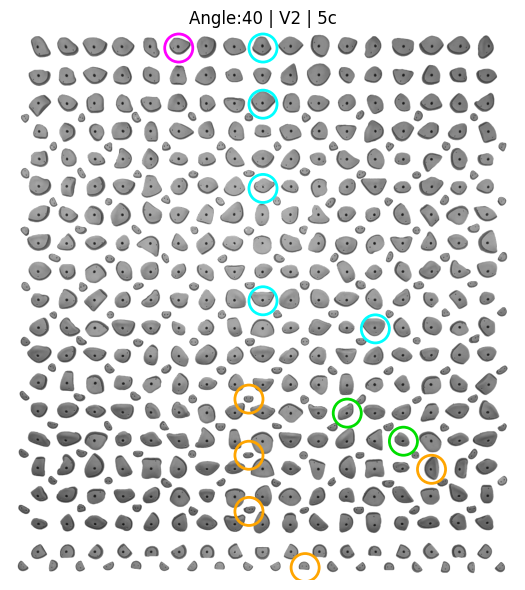

COMPARISON WITH DATASET

SAMPLE 59857
GROUND TRUTH: [BOS] angle30 grade14 feet1127 start1147 start1163 feet1182 hand1215 hand1236 feet1242 hand1270 hand1305 hand1324 hand1327 hand1361 finish1395 feet1459 feet1514 feet1531 [EOS] [PAD] [PAD] [PAD]
  PREFIX(0): 
  GENERATED:  angle45 grade22 feet1096 start1149 hand1234 hand1302 finish1387 feet1454

  PREFIX(3): angle30 grade14
  GENERATED:  angle30 grade14 feet1096 feet1130 start1149 feet1152 feet1166 hand1198 hand1236 hand1266 hand1302 hand1353 finish1390 feet1454 feet1457


SAMPLE 40269
GROUND TRUTH: [BOS] angle40 grade16 feet1081 feet1099 start1183 start1185 hand1234 hand1268 hand1283 hand1333 hand1353 finish1387 feet1478 feet1495 feet1514 feet1523 feet1549 feet1576 [EOS] [PAD] [PAD] [PAD]
  PREFIX(0): 
  GENERATED:  angle40 grade23 feet1081 start1149 hand1234 hand1287 hand1336 finish1383 feet1455

  PREFIX(3): angle40 grade16
  GENERATED:  angle40 grade16 start1149 feet1163 hand1200 hand1236 hand1268 hand1302 hand1334 hand1353 finish1

In [28]:
route = gpt.generate(prompt="angle40 grade15 hand1387 feet1138", max_length=25, temperature=0.7, top_k=5, do_sample=True, repetition_penalty=2)
print(route)
from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder(route)

gpt.generate_compare_with_dataset(datasets['train'], num_samples=2, prefix_lengths=[0,3], repetition_penalty=2)
gpt.visualize_predictions(datasets['test'], top_n= 4)
gpt.diagnose_model(datasets['train'])


In [29]:
load_gpt, load_trainer, load_tokenizer = KilterGPT.load_from_checkpoint(OUT_DIR, datasets)

Loading from: /content/drive/MyDrive/KilterTransformer/models/climb_gpt_new/20251111_061212_gpt_new/checkpoint-56000
Model loaded successfully with vocab_size=1932
Loaded training args from checkpoint


angle40 grade15 start1200 finish1353 start1149 hand1215 hand1234 hand1269 hand1302 finish1387


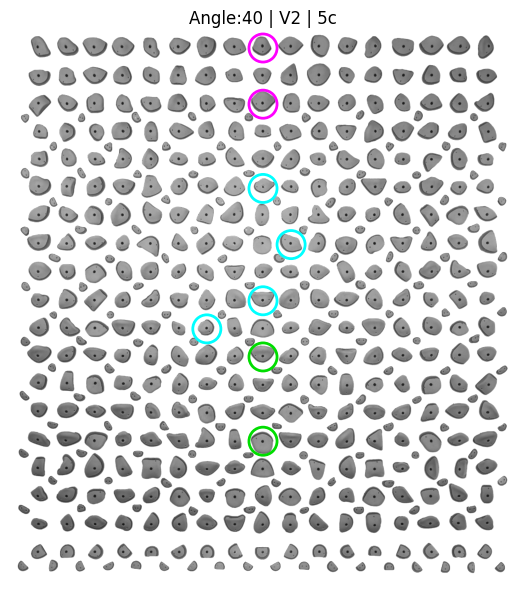

In [21]:
route = load_gpt.generate(prompt="angle40 grade15 start1200 finish1353", max_length=25, temperature=0.7, top_k=5, do_sample=True, repetition_penalty=2)
print(route)
from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder(route)

# load_gpt.generate_compare_with_dataset(datasets['train'], num_samples=2, prefix_lengths=[0,3], repetition_penalty=2)
# load_gpt.visualize_predictions(datasets['test'], top_n= 4)
# load_gpt.diagnose_model(datasets['train'])


# newloss

In [ ]:
project = "climb-gpt-new"
use_custom_loss = False #############
use_data_augment = True #############

run_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_{'defaultloss' if not use_custom_loss else 'newloss'}_{'noaugment' if not use_data_augment else 'augmented'}"

OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_new/{run_name}"
# OUT_DIR = f"models/climb_gpt_new/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dp = DataPreprocessing()
datasets = dp.load_climbs()

# 80-10-10 split
train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {
    'train': train_test['train'],
    'val': val_test['train'],
    'test': val_test['test']
}

tokenizer = train_tokenizer(datasets, OUT_DIR)
datasets = tokenize_datasets(datasets, tokenizer)

wandb.init(
    project=project,
    name=run_name,
    config=wandb_config,
)

gpt = KilterGPT(tokenizer=tokenizer,
                    use_custom_loss = use_custom_loss,
                    use_data_augment = use_data_augment,
                    device = device,
                    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="best",
    save_total_limit=2,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=2000,    ########
    save_steps=2000,    ########
    num_train_epochs=15,  ########
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # "wandb"
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name=run_name,
    )

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=gpt,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )


In [ ]:
trainer.evaluate(datasets['test'], metric_key_prefix='test')

In [ ]:
trainer.train()

In [ ]:
route = gpt.generate(prompt="angle40 grade15 hand1387 feet1138", max_length=25, temperature=0.7, top_k=5, do_sample=True, repetition_penalty=2)
print(route)
from src.visualization import Visualization
viz = Visualization()
viz.plot_boulder(route)

gpt.generate_compare_with_dataset(datasets['train'], num_samples=2, prefix_lengths=[0,3], repetition_penalty=2)
gpt.visualize_predictions(datasets['test'], top_n= 4)
gpt.diagnose_model(datasets['train'])


# augment

In [ ]:
class AugmentedRouteDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, tokenizer, num_augments=1):
        self.ds = dataset
        self.tokenizer = tokenizer
        self.num_augments = num_augments
        self.n = len(dataset)

    def __len__(self):
        return self.n * (self.num_augments + 1)  # originals + N augments

    def __getitem__(self, idx):
        base_idx = idx % self.n      # which real example in the base dataset
        aug_idx  = idx // self.n     # which augmentation slot (0 = original)

        example = self.ds[base_idx]
        tokens = example["input_ids"]

        if aug_idx > 0:  # 0 = original, others = augmented
            eos_idx = tokens.index(self.tokenizer.eos_token_id) if self.tokenizer.eos_token_id in tokens else len(tokens)
            prefix = tokens[:3]
            holds = tokens[3:eos_idx]
            tail = tokens[eos_idx:]

            random.shuffle(holds)          # in-place
            tokens = prefix + holds + tail


        max_len = tokenizer.model_max_length

        example["input_ids"] = tokens + [tokenizer.pad_token_id] * (max_len - len(tokens))
        example["labels"] = tokens + [-100] * (max_len - len(tokens)) #ignore_index for padding
        example["token_type_ids"] = [0] * max_len
        example["attention_mask"] = [1] * len(tokens) + [0] * (max_len - len(tokens))


        return example


augmented_dataset = AugmentedRouteDataset(datasets["train"], tokenizer, num_augments=1)
trainer.train_dataset = augmented_dataset
trainer.train()

In [ ]:
project = "climb-gpt-new"
use_custom_loss = False #############
use_data_augment = True #############

run_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_{'defaultloss' if not use_custom_loss else 'newloss'}_{'noaugment' if not use_data_augment else 'augmented'}"

OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_new/{run_name}"
# OUT_DIR = f"models/climb_gpt_new/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dp = DataPreprocessing()
datasets = dp.load_climbs()

# 80-10-10 split
train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {
    'train': train_test['train'],
    'val': val_test['train'],
    'test': val_test['test']
}

tokenizer = train_tokenizer(datasets, OUT_DIR)
datasets = tokenize_datasets(datasets, tokenizer)

wandb.init(
    project=project,
    name=run_name,
    config=wandb_config,
)

gpt = KilterGPT(tokenizer=tokenizer,
                    use_custom_loss = use_custom_loss,
                    use_data_augment = use_data_augment,
                    device = device,
                    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="best",
    save_total_limit=2,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=2000,    ########
    save_steps=2000,    ########
    num_train_epochs=15,  ########
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # "wandb"
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name=run_name,
    )

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=gpt,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )



In [ ]:
# trainer.train()

# newloss + augment

In [ ]:
project = "climb-gpt-new"
use_custom_loss = True #############
use_data_augment = True  #############

run_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_gpt_{'defaultloss' if not use_custom_loss else 'newloss'}_{'noaugment' if not use_data_augment else 'augmented'}"

OUT_DIR = f"/content/drive/MyDrive/KilterTransformer/models/climb_gpt_new/{run_name}"
# OUT_DIR = f"models/climb_gpt_new/{run_name}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dp = DataPreprocessing()
datasets = dp.load_climbs()

# 80-10-10 split
train_test = datasets.train_test_split(test_size=0.2, seed=42)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=42)

datasets = {
    'train': train_test['train'],
    'val': val_test['train'],
    'test': val_test['test']
}

tokenizer = train_tokenizer(datasets, OUT_DIR)
datasets = tokenize_datasets(datasets, tokenizer)

wandb.init(
    project=project,
    name=run_name,
    config=wandb_config,
)

gpt = KilterGPT(tokenizer=tokenizer,
                    use_custom_loss = use_custom_loss,
                    use_data_augment = use_data_augment,
                    device = device,
                    )
training_args = TrainingArguments(
    output_dir=OUT_DIR,
    eval_strategy="steps",
    save_strategy="best",
    save_total_limit=2,
    overwrite_output_dir=True,
    logging_steps=100,  # Log more frequently for wandb
    eval_steps=2000,    ########
    save_steps=2000,    ########
    num_train_epochs=15,  ########
    per_device_train_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=1e-5,
    weight_decay=0.01,
    adam_beta1=0.9,
    adam_beta2=0.999,
    report_to="wandb",  # "wandb"
    remove_unused_columns=False,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_dir=f"{OUT_DIR}/logs",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    save_safetensors=False,
    run_name=run_name,
    )

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=gpt,
    args=training_args,
    data_collator=data_collator,
    train_dataset=datasets["train"],
    eval_dataset=datasets["val"],
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )



# constrained gen

In [ ]:

class RouteConstraintProcessor(LogitsProcessor):
    """Enforce logical and structural constraints on climbing route generation."""

    def __init__(self, tokenizer, min_holds=5, max_holds=15):
        self.tokenizer = tokenizer
        self.min_holds = min_holds
        self.max_holds = max_holds

        vocab = tokenizer.get_vocab()
        self.angle_tokens = [tid for token, tid in vocab.items() if token.startswith('angle')]
        self.grade_tokens = [tid for token, tid in vocab.items() if token.startswith('grade')]
        self.start_tokens = [tid for token, tid in vocab.items() if token.startswith('start')]
        self.finish_tokens = [tid for token, tid in vocab.items() if token.startswith('finish')]
        self.hand_tokens = [tid for token, tid in vocab.items() if token.startswith('hand')]
        self.feet_tokens = [tid for token, tid in vocab.items() if token.startswith('feet')]
        self.all_hold_tokens = (
            self.start_tokens + self.hand_tokens + self.finish_tokens + self.feet_tokens
        )
        self.eos_token_id = tokenizer.eos_token_id

    def __call__(self, input_ids: torch.LongTensor, scores: torch.FloatTensor) -> torch.FloatTensor:

        for batch_idx in range(input_ids.shape[0]):
            decoded = self.tokenizer.decode(input_ids[batch_idx], skip_special_tokens=True)
            parts = decoded.split()

            print(parts)

            # --- Encourage correct order (angle first, grade second) ---
            has_angle = any(p.startswith("angle") for p in parts)
            has_grade = any(p.startswith("grade") for p in parts)

            # First position → encourage angle
            if len(parts) == 1 and not has_angle:
                scores[batch_idx, self.angle_tokens] += 3.0
            # Second position → encourage grade
            if len(parts) == 2 and has_angle and not has_grade:
                scores[batch_idx, self.grade_tokens] += 3.0

            # --- Prevent multiple angle/grade tokens ---
            if has_angle:
                scores[batch_idx, self.angle_tokens] = -float("inf")
            if has_grade:
                scores[batch_idx, self.grade_tokens] = -float("inf")

            # --- Skip rest until we have both angle+grade ---
            if not (has_angle and has_grade):
                continue

            holds = [p for p in parts[2:] if any(p.startswith(r) for r in ['start', 'hand', 'finish', 'feet'])]

            start_count = sum(h.startswith('start') for h in holds)
            finish_count = sum(h.startswith('finish') for h in holds)
            hand_count = sum(h.startswith('hand') for h in holds)
            feet_count = sum(h.startswith('feet') for h in holds)
            hold_count = len(holds)

            # --- EOS blocking until minimal structure is formed ---
            if hold_count < self.min_holds or start_count < 1 or finish_count < 1:
                scores[batch_idx, self.eos_token_id] = -float('inf')

            # --- Start/Finish limits ---
            if start_count >= 2:
                scores[batch_idx, self.start_tokens] = -float('inf')
            if finish_count >= 2:
                scores[batch_idx, self.finish_tokens] = -float('inf')

            # --- Force EOS once max reached ---
            if hold_count >= self.max_holds:
                scores[batch_idx, self.all_hold_tokens] = -float('inf')
                scores[batch_idx, self.eos_token_id] = 100.0  # strong bias toward EOS

        return scores


In [ ]:
@torch.no_grad()
def generate_with_constraint(
    self,
    prompt: str = "",
    max_length: int = 50,
    temperature: float = 1,
    top_k: Optional[int] = None,
    repetition_penalty: float = 1.2,
    do_sample: bool = True,
    min_holds: int = 5,
    max_holds: int = 15,
    ) -> str:
    """Autoregressively generate climbing route with structural constraints."""

    self.model.eval()
    self.model.to(self.device)

    # Initialize constraint processor
    processors = LogitsProcessorList([
        RouteConstraintProcessor(
            tokenizer=self.tokenizer,
            min_holds=min_holds,
            max_holds=max_holds
        )
    ])

    # Tokenize prompt
    if prompt:
        input_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(self.device)
        input_ids = input_ids[:, :-1]  # remove auto-added EOS
    else:
        input_ids = torch.tensor([[self.tokenizer.bos_token_id]], device=self.device)

    for _ in range(max_length - input_ids.shape[1]):
        outputs = self.model(input_ids)
        logits = outputs.logits[:, -1, :]  # (1, vocab_size)

        # Apply repetition penalty
        for token_id in set(input_ids[0].tolist()):
            if logits[0, token_id] < 0:
                logits[0, token_id] *= repetition_penalty
            else:
                logits[0, token_id] /= repetition_penalty

        # Apply temperature
        logits = logits / temperature

        # Apply top-k filtering
        if top_k is not None:
            indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
            logits[indices_to_remove] = -float("Inf")

        # Apply constraint processor
        logits = processors(input_ids, logits)

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample or greedy
        if do_sample:
            next_token = torch.multinomial(probs, num_samples=1)
        else:
            next_token = torch.argmax(probs, dim=-1, keepdim=True)

        # Append token
        input_ids = torch.cat([input_ids, next_token], dim=-1)

        # Stop at EOS
        if next_token.item() == self.tokenizer.eos_token_id:
            break

    generated_text = self.tokenizer.decode(input_ids[0], skip_special_tokens=True)
    return generated_text


KilterGPTExtended.generate_with_constraint = generate_with_constraint

load_gpt.generate_with_constraint(prompt="")

[]
['feet1492']
['feet1492', 'angle35']
['feet1492', 'angle35', 'feet1451']
['feet1492', 'angle35', 'feet1451', 'hand1126']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236', 'hand1302']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236', 'hand1302', 'hand1514']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236', 'hand1302', 'hand1514', 'hand1216']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236', 'hand1302', 'hand1514', 'hand1216', 'finish1490']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236', 'hand1302', 'hand1514', 'hand1216', 'finish1490', 'hand1081']
['feet1492', 'angle35', 'feet1451', 'hand1126', 'start1254', 'start1236', 'hand1302', 'hand1514', 'hand1216', 'finish1490', 'hand1081', 'start1153']
['feet1492', 'angle35', 'feet1451', 'h

'feet1492 angle35 feet1451 hand1126 start1254 start1236 hand1302 hand1514 hand1216 finish1490 hand1081 start1153 hand1209'